In [1]:
from gradio_client import Client   # for api use

import ast                         # for text to list conversion (make data useful)
import pandas as pd                # for easy data use; you can use polars or whatever you like

# Accessing the API

Accessing the API is simple. You pass your key to the client, and then you will see a message the API has loaded.

In [2]:
token = '../api_creds/vi_key_1.csv'

# load my key
df = pd.read_csv(token) # easy and lazy lol; using pandas anyway ;p
api_key = df['key'][0]  # easy and lazy lol; using pandas anyway ;p

# connect to api
client = Client("verdantintel/verdanteye", token=api_key)

Loaded as API: https://verdantintel-verdanteye.hf.space


# Helper Function

In [3]:
def ask_api(client, question):

    answer = client.predict(question=question, api_name="/predict")
    
    answer = ast.literal_eval(answer)

    return answer

# Searching for Data

In [16]:
question = 'what is happening in Michigan in March 2026?'

answer = ask_api(client, question)
len(answer)

1714

In [17]:
answer[0]

{'claim': 'A Novi girl and an infant were killed in a dog attack.',
 'url': 'https://freep.com/story/news/local/novi/2026/03/17/novi-girl-infant-killed-dog-attack-death-police/89196462007/',
 'domain': 'freep.com',
 'url_domain': 'freep.com',
 'date_added': '2026-03-17 18:55:31'}

In [18]:
df = pd.DataFrame(answer)
df['date_added'] = pd.to_datetime(df['date_added'], utc=True)
df['date_added'] = df['date_added'].dt.tz_convert('America/Los_Angeles') # put into my timezone
df.sort_values('date_added', ascending=False, inplace=True)
df.head()

# ran at 9:14pm > data from 9:12:50 ... nice

,claim,url,domain,url_domain,date_added
0,A Novi girl and an infant were killed in a dog...,https://freep.com/story/news/local/novi/2026/0...,freep.com,freep.com,2026-03-17 11:55:31-07:00
1,Unauthorized users are attempting to access ov...,https://wilx.com/2026/03/17/unauthorized-users...,wilx.com,wilx.com,2026-03-17 11:44:32-07:00
2,Information about Michigan's statewide tornado...,https://clickondetroit.com/news/2026/03/17/mic...,clickondetroit.com,clickondetroit.com,2026-03-17 11:30:44-07:00
3,A man and woman in Clinton Township have died ...,https://www.macombdaily.com/2026/03/17/clinton...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00
4,A man who shot his co-worker at Corewell Healt...,https://www.macombdaily.com/2026/03/17/man-who...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00


In [15]:
df.shape

(1713, 5)

# Clustering

Clustering is useful for seeing the kinds of things that are happening. If you want to do trend analysis, start with clustering or filtering. You will want to have clustering in your skillset/toolset. Here is my graph+nlp approach, my own approach.

Tweak the similarity threshold to get what you want. 1 is exact match. 0 is no match. 0.5-0.8 is typically pretty sweet, but it depends on what you are doing. Sometimes lower is useful. Sometimes very high is useful. Be thoughtful about what you are trying to do and it will make sense. Ask me if you would like to learn more.

In [21]:
import pandas as pd
import numpy as np
import networkx as nx
import community as community_louvain

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [22]:
def cluster_text(texts, similarity_threshold=0.5):

    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        lowercase=True,
        sublinear_tf=True
    )

    tfidf_matrix = vectorizer.fit_transform(texts)

    similarity_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)
    adj_matrix = (similarity_matrix > similarity_threshold).astype(int)

    G = nx.from_numpy_array(adj_matrix)
    partition = community_louvain.best_partition(G, resolution=0.5, random_state=1337) 

    return list(partition.values())

In [23]:
df.head()

,claim,url,domain,url_domain,date_added
0,A Novi girl and an infant were killed in a dog...,https://freep.com/story/news/local/novi/2026/0...,freep.com,freep.com,2026-03-17 11:55:31-07:00
1,Unauthorized users are attempting to access ov...,https://wilx.com/2026/03/17/unauthorized-users...,wilx.com,wilx.com,2026-03-17 11:44:32-07:00
2,Information about Michigan's statewide tornado...,https://clickondetroit.com/news/2026/03/17/mic...,clickondetroit.com,clickondetroit.com,2026-03-17 11:30:44-07:00
3,A man and woman in Clinton Township have died ...,https://www.macombdaily.com/2026/03/17/clinton...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00
4,A man who shot his co-worker at Corewell Healt...,https://www.macombdaily.com/2026/03/17/man-who...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00


In [36]:
df['cluster'] = cluster_text(df['claim'], similarity_threshold=0.4) # reducing to capture broader topics
df.head()

,claim,url,domain,url_domain,date_added,cluster
0,A Novi girl and an infant were killed in a dog...,https://freep.com/story/news/local/novi/2026/0...,freep.com,freep.com,2026-03-17 11:55:31-07:00,0
1,Unauthorized users are attempting to access ov...,https://wilx.com/2026/03/17/unauthorized-users...,wilx.com,wilx.com,2026-03-17 11:44:32-07:00,1
2,Information about Michigan's statewide tornado...,https://clickondetroit.com/news/2026/03/17/mic...,clickondetroit.com,clickondetroit.com,2026-03-17 11:30:44-07:00,2
3,A man and woman in Clinton Township have died ...,https://www.macombdaily.com/2026/03/17/clinton...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00,3
4,A man who shot his co-worker at Corewell Healt...,https://www.macombdaily.com/2026/03/17/man-who...,macombdaily.com,macombdaily.com,2026-03-17 11:28:12-07:00,4


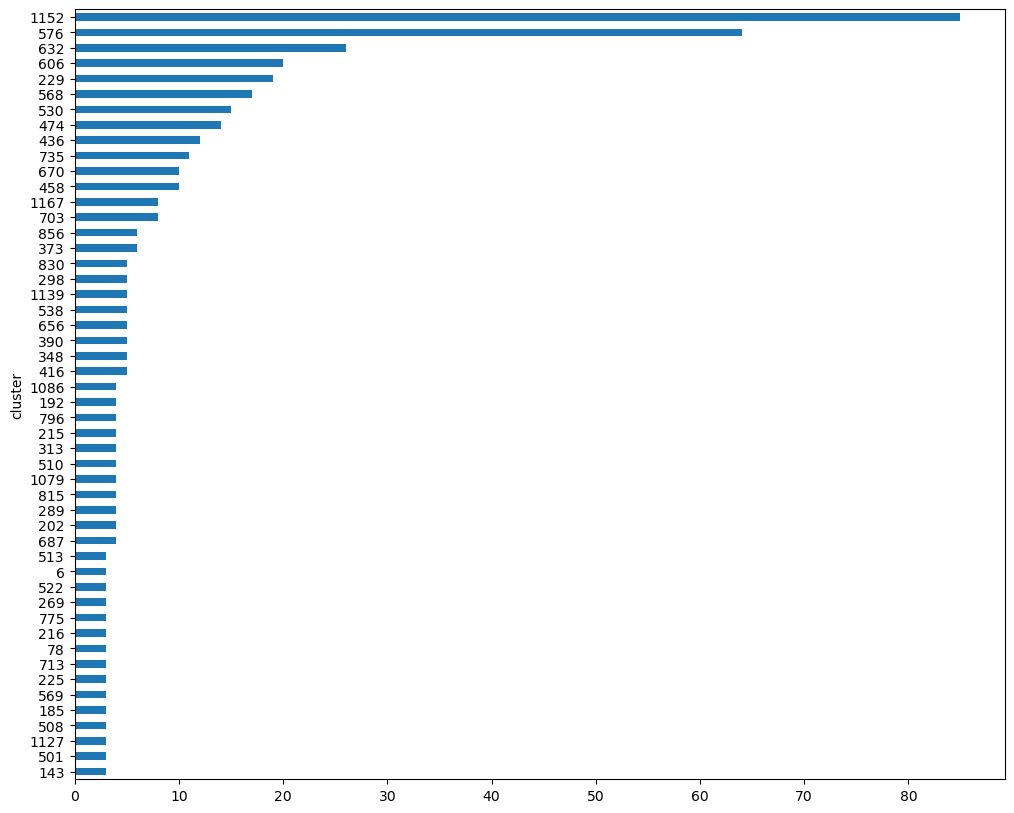

In [37]:
df['cluster'].value_counts()[0:50].plot.barh(figsize=(12,10)).invert_yaxis()

In [38]:
top_clusters = df['cluster'].value_counts().index.values
top_clusters

array([1152,  576,  632, ...,  753,  754, 1171], dtype=int64)

In [39]:
for cluster in top_clusters[0:50]:
    
    print('cluster: {}'.format(cluster))
    
    cluster_data = df[df['cluster']==cluster].head(20)['claim'].values
    print(cluster_data)
    
    print()

cluster: 1152
['Event scheduled at Muskegon Area District Library'
 'Another event scheduled at Muskegon Area District Library'
 'Another event is scheduled at the Muskegon Area District Library.'
 'An event is scheduled at the Muskegon Area District Library.'
 'There is an event listed on the Muskegon Area District Library website.'
 'Event listed at Muskegon Area District Library'
 'An event hosted by Muskegon Area District Library.'
 'An event is scheduled at Muskegon Area District Library.'
 'Another event is scheduled at Muskegon Area District Library.'
 "An event is listed on the Muskegon Area District Library's website."
 'Event listing for a specific event in Muskegon'
 'Event information available on Muskegon Area District Library.'
 'Event information available on Muskegon Area District Library.'
 'Event information available on Muskegon Area District Library.'
 'Information about a specific event hosted by the Muskegon Area District Library.'
 'Event listing for a specific e

In [36]:
# less than five minute OSINT, end at 9:19pm